In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

In [ ]:
dataset_path = "/content/drive/MyDrive/AIML 2026/SEM 4 Final Project/groundnutleafdataset"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.2,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1376 images belonging to 5 classes.
Found 344 images belonging to 5 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyboardInterrupt: 

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.7658 - loss: 0.6975 - val_accuracy: 0.8459 - val_loss: 0.4831
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.7630 - loss: 0.6117 - val_accuracy: 0.7965 - val_loss: 0.6949
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.8192 - loss: 0.5405 - val_accuracy: 0.8023 - val_loss: 0.6834
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.8397 - loss: 0.4534 - val_accuracy: 0.7587 - val_loss: 0.9715
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8433 - loss: 0.4323 - val_accuracy: 0.7267 - val_loss: 0.9902
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.8750 - loss: 0.4019 - val_accuracy: 0.7733 - val_loss: 0.9966
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.8772 - loss: 0.3695 - val_accuracy: 0.7558 - val_loss: 1.0442
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.8787 - loss: 0.3917 - val_accuracy: 0.7558 - v

In [ ]:
model.save("/content/drive/MyDrive/groundnut_disease_model.keras")

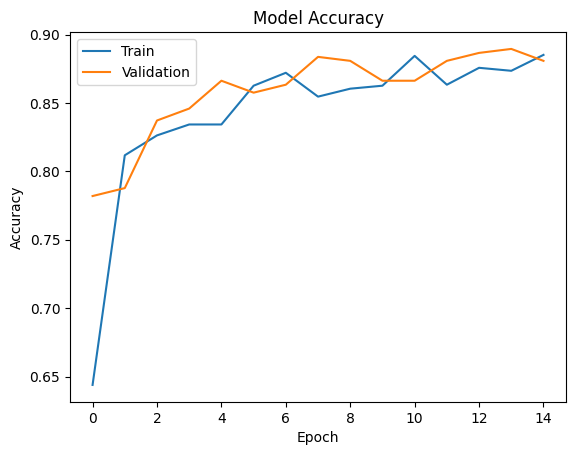

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.8851743936538696
Final Validation Accuracy: 0.8808139562606812


In [ ]:
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

Best Validation Accuracy: 0.8895348906517029


In [ ]:
test_loss, test_accuracy = model.evaluate(train_generator)

43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8929 - loss: 0.3672


In [ ]:
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 89.17%


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/AIML 2026/SEM 4 Final Project/groundnut_disease_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 29 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
print(train_generator.class_indices)

NameError: name 'train_generator' is not defined

In [ ]:
class_names = [
    "ALTERNARIA LEAF SPOT",
    "HEALTHY",
    "LEAF SPOT (EARLY AND LATE)",
    "ROSETTE",
    "RUST"
]

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving helthy1.jpg to helthy1.jpg


In [ ]:
img_path = "/content/helthy1.jpg"

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Disease: HEALTHY
Confidence: 99.42929 %


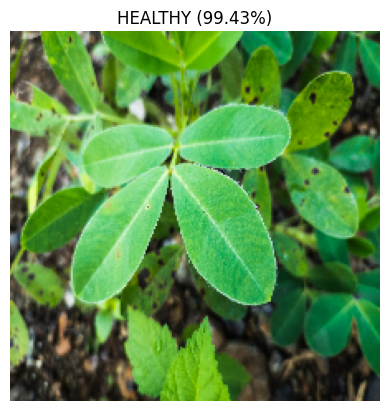

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()